# MDA Topic Modelling Pipeline (LDA)

**Pipeline steps:**
1. Load & reshape data
2. Build dictionary + corpus
3. Train initial LDA model
4. pyLDAvis visualisation
5. Perplexity evaluation
6. Coherence score
7. Grid search over number of topics
8. Evaluation plot (coherence + perplexity)
9. Select best model & assign dominant topic per sentence
10. Document-level topic distribution

## 0. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

import gensim
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()
print('All imports successful.')

All imports successful.


In [ ]:
!pip install --upgrade openpyxl

## 1. Load & Reshape Data

change to 1 sentence per row

In [ ]:
EXCEL_PATH  = 'mda_processed_sample.xlsx'  
SHEET_NAME  = 'after_stopword_removal'     
DOC_COL     = 'doc'                        

df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
print(f'Loaded: {df.shape[0]} documents, {df.shape[1]} columns')
df.head(2)

Loaded: 64 documents, 452 columns


,doc,sent_1,sent_2,sent_3,sent_4,sent_5,sent_6,sent_7,sent_8,sent_9,...,sent_442,sent_443,sent_444,sent_445,sent_446,sent_447,sent_448,sent_449,sent_450,sent_451
0,NVIDIA_10-K_2010-03-18_MDA.txt,"overview, helped, awaken, world, power, comput...","expertise, programmable, gpus, led, breakthrou...","serve, entertainment, consumer, market, geforc...","last, several, years, operated, reported, four...","however, effective, first_year, longer, separa...","gpu_business, comprised, primarily, geforce, p...","psb, comprised, quadro_professional, workstati...","mcp, business, reported, year, comprised, prim...","ion, family, products, addresses, integrated, ...",...,"although, number, units, estimate, impacted, i...","weak_diepackaging_material, combination, used,...","continue, seek, access, insurance, coverage, r...","however_assurance, made, aggregate, million, c...","september, october, november, several, putativ...","please, note, financial, information_regarding...","contractual_obligations, represents, unrecogni...","unable, reasonably_estimate, timing_potential,...","adoption_new, accounting, pronouncements, plea...","recently, issued, accounting, pronouncements, ..."
1,NVIDIA_10-K_2011-03-16_MDA.txt,"overview, invented, graphics, processing, unit...","since, strived, new, standards, visual_computi...","expertise, programmable, gpus, computer-system...","strategically, investing, three, major, areas,...","serve, visual_computing, market, consumer, gef...","three, primary, financial, gpu, professional_s...","years, operated, reported, four, major, produc...","however, first_year, began, reporting, interna...","comparative, periods, presented, reflect, change",...,"recommended, customers, consider, changing, th...","intend, fully, support, custom, ers, repair, r...","weak_diepackaging_material, combination, used,...","september, october, november, several, putativ...","please, note, financial, information_regarding...","contractual_obligations, represents, unrecogni...","unable, reasonably_estimate, timing_potential,...","adoption_new, accounting, pronouncements, plea...","recently, issued, accounting, pronouncements, ...",NaN


In [ ]:
# Identify sentence columns
sent_cols = [c for c in df.columns if c.startswith('sent_')]
print(f'Found {len(sent_cols)} sentence columns')

#change to long format
df_melted = df.melt(
    id_vars=DOC_COL,
    value_vars=sent_cols,
    var_name='sent_id',
    value_name='tokens'
).dropna(subset=['tokens'])

# Each cell is a comma-separated token string -- split into a list
df_melted['token_list'] = df_melted['tokens'].apply(
    lambda x: [t.strip() for t in str(x).split(',') if t.strip()]
)

# Drop empty sentences
df_melted = df_melted[df_melted['token_list'].map(len) > 0].reset_index(drop=True)

print(f'Total sentences after melting: {len(df_melted)}')
df_melted.head(3)

Found 451 sentence columns
Total sentences after melting: 11881


,doc,sent_id,tokens,token_list
0,NVIDIA_10-K_2010-03-18_MDA.txt,sent_1,"overview, helped, awaken, world, power, comput...","[overview, helped, awaken, world, power, compu..."
1,NVIDIA_10-K_2011-03-16_MDA.txt,sent_1,"overview, invented, graphics, processing, unit...","[overview, invented, graphics, processing, uni..."
2,NVIDIA_10-K_2012-03-13_MDA.txt,sent_1,"overview, known, millions, around, world, crea...","[overview, known, millions, around, world, cre..."


## 2. Build Dictionary & Corpus

In [ ]:
# Filtering out extremes
NO_BELOW = 5    # ignore tokens appearing in fewer than N sentences
NO_ABOVE = 0.5  # ignore tokens appearing in more than X% of sentences


mda_docs = df_melted['token_list'].tolist()

mda_dictionary = Dictionary(mda_docs)
print(f'Dictionary size before filtering: {len(mda_dictionary)}')

mda_dictionary.filter_extremes(no_below=NO_BELOW, no_above=NO_ABOVE)
print(f'Dictionary size after filtering:  {len(mda_dictionary)}')

mda_vecs = [mda_dictionary.doc2bow(doc) for doc in mda_docs]
print(f'Corpus size: {len(mda_vecs)} documents')

Dictionary size before filtering: 5544
Dictionary size after filtering:  3282
Corpus size: 11881 documents


## 3. Train Initial LDA Model

We train a first model with a chosen `num_topics` as a starting point. This is used for the pyLDAvis visualisation and quick evaluation before the grid search.

In [ ]:
# CONFIG -----------------------------------------------------------------------
INIT_NUM_TOPICS = 10  # starting point -- will be optimised in grid search
PASSES          = 10  #number of times the model goes through the entire dataset during training
RANDOM_STATE    = 1

print(f'Training LDA with {INIT_NUM_TOPICS} topics...')
mda_lda = LdaModel(
    corpus=mda_vecs,
    id2word=mda_dictionary,
    num_topics=INIT_NUM_TOPICS,
    passes=PASSES,
    alpha='auto',      # learns document-topic prior from data
    eta='auto',        # learns topic-word prior from data
    random_state=RANDOM_STATE
)
print('Done.')

print('\nTop 5 words per topic:')
for i, topic in mda_lda.show_topics(num_topics=INIT_NUM_TOPICS, num_words=5, formatted=True):
    print(f'  Topic {i}: {topic}')

Training LDA with 10 topics...
Done.

Top 5 words per topic:
  Topic 0: 0.031*"revenue" + 0.022*"products" + 0.017*"federal" + 0.017*"gaming" + 0.015*"gpus"
  Topic 1: 0.028*"may" + 0.028*"new" + 0.017*"discussion" + 0.014*"stock" + 0.014*"accounting"
  Topic 2: 0.033*"inventory" + 0.024*"obligations" + 0.024*"recognized" + 0.020*"previously" + 0.020*"sales"
  Topic 3: 0.069*"year" + 0.034*"increased" + 0.033*"increase" + 0.032*"sales" + 0.026*"revenue"
  Topic 4: 0.020*"margin" + 0.019*"investment" + 0.015*"certain" + 0.013*"market" + 0.012*"current"
  Topic 5: 0.125*"million" + 0.025*"respectively" + 0.021*"gross" + 0.021*"revenue" + 0.021*"expense"
  Topic 6: 0.022*"payments" + 0.022*"losses" + 0.018*"costs" + 0.017*"common_stock" + 0.016*"expect"
  Topic 7: 0.059*"cash" + 0.055*"million" + 0.045*"year" + 0.040*"billion" + 0.029*"months"
  Topic 8: 0.028*"products" + 0.026*"additional" + 0.019*"investments" + 0.014*"costs" + 0.013*"estimated"
  Topic 9: 0.036*"financial" + 0.032*"no

## 4. pyLDAvis Interactive Visualisation

In [ ]:
print('Preparing pyLDAvis (may take a moment)...')
vis = gensimvis.prepare(mda_lda, mda_vecs, mda_dictionary)
vis

Preparing pyLDAvis (may take a moment)...


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.157804  0.135585       1        1  14.871076
0     -0.067463  0.275571       2        1  13.097053
1     -0.181891 -0.024627       3        1  12.571562
7      0.270363 -0.052917       4        1  10.292249
4     -0.144856 -0.148401       5        1  10.113954
8     -0.156004 -0.001328       6        1   9.150719
5      0.231078 -0.008066       7        1   9.033324
9     -0.067177 -0.224666       8        1   8.859614
2      0.073556 -0.117863       9        1   6.834037
6     -0.115411  0.166712      10        1   5.176412, topic_info=                   Term         Freq        Total Category  logprob  loglift
499             million  2729.000000  2729.000000  Default  30.0000  30.0000
257                year  2186.000000  2186.000000  Default  29.0000  29.0000
1402               cash   890.000000   890.000000  Default  28.0000  28.0000
519           increased   744.000000   744.000000  Default  27.0000  27.0000
371             billion   688.000000   688.000000  Default  26.0000  26.0000
...                 ...          ...          ...      ...      ...      ...
255                  us    90.712478   510.135909  Topic10  -4.4050   1.2341
662           component    51.041046    80.178968  Topic10  -4.9800   2.5094
301             support    54.785330   150.321267  Topic10  -4.9093   1.9517
162                well    54.151575   194.557941  Topic10  -4.9209   1.6821
2229  intangible_assets    51.510137   103.985077  Topic10  -4.9709   2.2586

[521 rows x 6 columns], token_table=      Topic      Freq                       Term
term                                            
2259      7  0.980705                  accounted
1386      3  0.996942                 accounting
2953      3  0.985175  accounting_pronouncements
2832     10  0.989533                   accounts
1787      6  0.993751        accounts_receivable
...     ...       ...                        ...
122       7  0.643163                      years
122       9  0.190939                      years
122      10  0.160791                      years
2562      7  0.364603         years_respectively
2562      9  0.631044         years_respectively

[756 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 2, 8, 5, 9, 6, 10, 3, 7])

## 5. Perplexity (Initial Model)
**Lower is better.**

In [ ]:
perplex = mda_lda.log_perplexity(mda_vecs)
print(f'Log Perplexity (initial model, {INIT_NUM_TOPICS} topics): {perplex:.4f}')

Log Perplexity (initial model, 10 topics): -7.0278
(Lower is better)


## 6. Coherence Score (Initial Model)

`c_v` coherence measures semantic similarity of top words within each topic. **Higher is better.**

In [ ]:
coherence_model = CoherenceModel(
    model=mda_lda,
    texts=mda_docs,
    dictionary=mda_dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print(f'Coherence Score c_v (initial model, {INIT_NUM_TOPICS} topics): {coherence_score:.4f}')
print('(Higher is better)')

Coherence Score c_v (initial model, 10 topics): 0.4246
(Higher is better)


## 7. Grid Search — Optimal Number of Topics

Train LDA for a range of topic counts, recording coherence and perplexity for each.

In [ ]:
# CONFIG -----------------------------------------------------------------------
TOPIC_RANGE_START = 2
TOPIC_RANGE_END   = 20  # exclusive
TOPIC_RANGE_STEP  = 2
# ------------------------------------------------------------------------------

model_list        = []
coherence_values  = []
perplexity_values = []
model_topics      = []

print(f'Grid search: {TOPIC_RANGE_START} to {TOPIC_RANGE_END} topics (step {TOPIC_RANGE_STEP})')
print(f'Started: {datetime.datetime.now()}\n')

for num_topics in range(TOPIC_RANGE_START, TOPIC_RANGE_END, TOPIC_RANGE_STEP):
    model = LdaModel(
        corpus=mda_vecs,
        id2word=mda_dictionary,
        num_topics=num_topics,
        passes=PASSES,
        alpha='auto',
        eta='auto',
        random_state=RANDOM_STATE
    )
    cv   = CoherenceModel(model=model, texts=mda_docs,
                          dictionary=mda_dictionary, coherence='c_v').get_coherence()
    perp = model.log_perplexity(mda_vecs)

    model_list.append(model)
    model_topics.append(num_topics)
    coherence_values.append(cv)
    perplexity_values.append(perp)

    print(f'  Topics: {num_topics:>3} | Coherence (c_v): {cv:.4f} | Log Perplexity: {perp:.2f}')

print(f'\nFinished: {datetime.datetime.now()}')

Grid search: 2 to 20 topics (step 2)
Started: 2026-03-22 22:30:16.698913

  Topics:   2 | Coherence (c_v): 0.3305 | Log Perplexity: -7.10
  Topics:   4 | Coherence (c_v): 0.3661 | Log Perplexity: -6.95
  Topics:   6 | Coherence (c_v): 0.3840 | Log Perplexity: -7.02
  Topics:   8 | Coherence (c_v): 0.3977 | Log Perplexity: -7.02
  Topics:  10 | Coherence (c_v): 0.4246 | Log Perplexity: -7.03
  Topics:  12 | Coherence (c_v): 0.4085 | Log Perplexity: -7.03
  Topics:  14 | Coherence (c_v): 0.4015 | Log Perplexity: -7.61
  Topics:  16 | Coherence (c_v): 0.4085 | Log Perplexity: -9.90
  Topics:  18 | Coherence (c_v): 0.4344 | Log Perplexity: -11.05

Finished: 2026-03-22 22:37:36.795619


## 8. Evaluation Plot

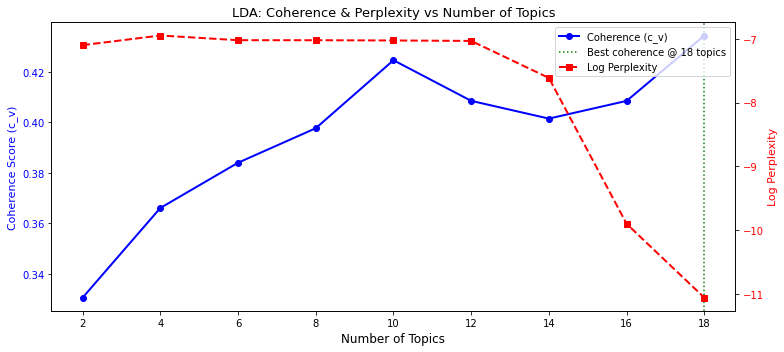


Best coherence: 0.4344 at 18 topics


In [ ]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(model_topics, coherence_values,  'b-o',  linewidth=2, markersize=6, label='Coherence (c_v)')
ax2.plot(model_topics, perplexity_values, 'r--s', linewidth=2, markersize=6, label='Log Perplexity')

# Mark the best coherence point
best_idx = coherence_values.index(max(coherence_values))
ax1.axvline(x=model_topics[best_idx], color='green', linestyle=':', linewidth=1.5,
            label=f'Best coherence @ {model_topics[best_idx]} topics')

ax1.set_xlabel('Number of Topics', fontsize=12)
ax1.set_ylabel('Coherence Score (c_v)', color='b', fontsize=11)
ax2.set_ylabel('Log Perplexity', color='r', fontsize=11)
ax1.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('LDA: Coherence & Perplexity vs Number of Topics', fontsize=13)
plt.tight_layout()
plt.savefig('topic_eval_plot.png', dpi=150)
plt.show()

print(f'\nBest coherence: {max(coherence_values):.4f} at {model_topics[best_idx]} topics')

## 9. Select Best Model & Assign Dominant Topic per Sentence

Best model is selected automatically by highest `c_v` coherence.
Override `best_idx` manually if you prefer a different point on the plot (e.g. `best_idx = 3`).

In [ ]:
# Auto-select of best number of topics
best_idx   = coherence_values.index(max(coherence_values))
best_model = model_list[best_idx]
best_n     = model_topics[best_idx]

print(f'Selected model: {best_n} topics')
print(f'  Coherence (c_v): {coherence_values[best_idx]:.4f}')
print(f'  Log Perplexity:  {perplexity_values[best_idx]:.2f}')

print('\nTop 10 words per topic:')
for i, topic in best_model.show_topics(num_topics=best_n, num_words=10, formatted=True):
    print(f'  Topic {i}: {topic}')

Selected model: 18 topics
  Coherence (c_v): 0.4344
  Log Perplexity:  -11.05

Top 10 words per topic:
  Topic 0: 0.069*"revenue" + 0.028*"capital" + 0.025*"payment" + 0.024*"price" + 0.020*"future" + 0.020*"fair" + 0.019*"gaming" + 0.019*"interest_rates" + 0.018*"sequentially" + 0.018*"balance"
  Topic 1: 0.046*"may" + 0.026*"stock" + 0.022*"results" + 0.021*"subject" + 0.020*"settlement" + 0.020*"operations" + 0.018*"shares" + 0.016*"repurchase" + 0.015*"financing" + 0.015*"accounting"
  Topic 2: 0.108*"issued" + 0.067*"years" + 0.064*"expenses" + 0.057*"adoption" + 0.039*"agreement" + 0.035*"applicable" + 0.032*"net_income" + 0.030*"operating" + 0.026*"expect" + 0.024*"one"
  Topic 3: 0.089*"gross" + 0.055*"margin" + 0.037*"purchase" + 0.035*"sales" + 0.034*"portfolio" + 0.029*"respectively" + 0.028*"taxes" + 0.026*"inventory" + 0.026*"previously" + 0.022*"gpu"
  Topic 4: 0.092*"cash" + 0.049*"billion" + 0.035*"marketable_securities" + 0.034*"income" + 0.031*"investment" + 0.029*"ma

Claude:
Looking at the top words in each topic, here are suggested labels with reasoning:

| Topic | Suggested Label | Rationale |
|---|---|---|
| **0** | **Revenue & Capital Allocation** | revenue, capital, payment, price, fair, interest_rates, balance — mix of top-line and balance sheet language |
| **1** | **Legal & Corporate Governance** | settlement, shares, repurchase, subject, accounting, financing — shareholder and legal proceedings language |
| **2** | **Accounting Standards & Agreements** | issued, adoption, agreement, applicable, net_income, operating — adoption of new accounting pronouncements |
| **3** | **Gross Margin & Inventory Management** | gross, margin, sales, inventory, taxes, portfolio, purchase — cost management and profitability discussion |
| **4** | **Cash & Investment Portfolio** | cash, billion, marketable_securities, investment, assets, income — liquidity and investment holdings |
| **5** | **Valuation & Fair Value Estimation** | fair_value, rates, assumptions, reporting, value, operating_expenses — goodwill/impairment testing and estimates |
| **6** | **Tax & Deferred Tax Assets** | tax, tax_benefit, excess, obligations, inventory, basis — income tax accounting and carryforwards |
| **7** | **Year-over-Year Financial Performance** | compared, total, charges, revenue, million, gross_margin, research — segment-level period comparisons |
| **8** | **Product Segments & Business Overview** | tegra, gpu_business, products, devices, processor, arrangements — business segment descriptions |
| **9** | **Sales Drivers & Revenue Changes** | sales, increase, decrease, higher, lower, primarily_due, liquidity — commentary on revenue fluctuations |
| **10** | **Technology Platform & GPU Innovation** | gpus, platform, software, new, announced, ai, currently — product launches and technology strategy |
| **11** | **Risk Factors & Contingent Liabilities** | estimated, impacted, income_tax, could, customers, costs, amount — forward-looking risk disclosures |
| **12** | **Product Costs & Manufacturing** | cost, costs, demand, testing, support, new, based — cost of revenue and production discussion |
| **13** | **Quantitative Financial Figures** | million (0.249!), investments, net, recorded, changes, development — heavy dollar-figure reporting |
| **14** | **Boilerplate Cross-References** | financial, note, please, discussion, additional, recently, information — standard "see Note X" filler text |
| **15** | **Temporal Period References** | year (0.242!), first, months, nine, half, second, third — time period markers, likely quarterly comparisons |
| **16** | **Compensation & Geographic Earnings** | expense, compensation, recognized, united_states, outside, payments, convertible — stock comp and offshore earnings |
| **17** | **Market Strategy & Technology Outlook** | market, cloud, technology, plans, system, unable, market_conditions — forward-looking strategic discussion |

---

A few notes worth flagging:

**Topics 14 and 15 are procedural/structural noise.** Topic 14 (`note, please, discussion, financial`) is almost entirely boilerplate cross-reference language. Topic 15 (`year, first, months, nine`) is dominated by temporal markers. These are artifacts of the MDA structure rather than substantive topics — you may want to either exclude them from analysis or note them as such.

**Topic 13** is dominated by `million` at 0.249, which suggests it's capturing quantitative reporting sentences broadly rather than a coherent theme. It may be worth checking whether `million` should have been filtered out as a high-frequency functional word.

**Topics 8 and 10** are both product-related but at different levels — Topic 8 is more about segment structure/overview while Topic 10 is more about specific technology and launches. That distinction seems meaningful and worth preserving as separate labels.

In [ ]:
def format_topics_sentences(ldamodel, corpus, df_melted):
    """
    For each sentence, find its dominant topic, contribution %, and top keywords.
    Returns a DataFrame with doc, sent_id, dominant topic, contribution, keywords, text.
    """
    rows = []
    for i, row_dist in enumerate(ldamodel[corpus]):
        row_dist = sorted(row_dist, key=lambda x: x[1], reverse=True)
        if not row_dist:
            continue
        topic_num, prop_topic = row_dist[0]
        wp             = ldamodel.show_topic(topic_num, topn=10)
        topic_keywords = ', '.join([word for word, _ in wp])
        rows.append({
            'doc':                df_melted.iloc[i]['doc'],
            'sent_id':            df_melted.iloc[i]['sent_id'],
            'Dominant_Topic':     int(topic_num),
            'Topic_Perc_Contrib': round(prop_topic, 4),
            'Topic_Keywords':     topic_keywords,
            'Text':               ' '.join(df_melted.iloc[i]['token_list'])
        })
    return pd.DataFrame(rows)


df_results = format_topics_sentences(best_model, mda_vecs, df_melted)
print(f'Assigned dominant topics to {len(df_results)} sentences.')
df_results.head(10)

Assigned dominant topics to 11881 sentences.


,doc,sent_id,Dominant_Topic,Topic_Perc_Contrib,Topic_Keywords,Text
0,NVIDIA_10-K_2010-03-18_MDA.txt,sent_1,17,0.3736,"market, unit, market_conditions, products, clo...",overview helped awaken world power computer_gr...
1,NVIDIA_10-K_2011-03-16_MDA.txt,sent_1,17,0.7967,"market, unit, market_conditions, products, clo...",overview invented graphics processing unit gpu
2,NVIDIA_10-K_2012-03-13_MDA.txt,sent_1,5,0.6633,"rates, fair_value, fourth_year, value, reporti...",overview known millions around world creating ...
3,NVIDIA_10-K_2013-03-12_MDA.txt,sent_1,10,0.4723,"federal, announced, new, using, platform, soft...",overview visual_computing connecting people po...
4,NVIDIA_10-K_2014-03-13_MDA.txt,sent_1,17,0.5712,"market, unit, market_conditions, products, clo...",overview visual_computing
5,NVIDIA_10-K_2015-03-12_MDA.txt,sent_1,15,0.5466,"year, first, million, months, nine, respective...",overview_businesses dedicated advancing visual...
6,NVIDIA_10-K_2016-03-17_MDA.txt,sent_1,16,0.5488,"expense, us, recognized, payments, united_stat...",overview_businesses world leader visual_computing
7,NVIDIA_10-K_2017-03-01_MDA.txt,sent_1,14,0.4379,"financial, note, discussion, activities, pleas...",overview_businesses starting focus_pc_graphics...
8,NVIDIA_10-K_2018-02-28_MDA.txt,sent_1,14,0.4379,"financial, note, discussion, activities, pleas...",overview_businesses starting focus_pc_graphics...
9,NVIDIA_10-K_2019-02-21_MDA.txt,sent_1,14,0.4379,"financial, note, discussion, activities, pleas...",overview_businesses starting focus_pc_graphics...


## 10. Document-Level Topic Distribution

Aggregates sentence-level assignments to show which topics dominate each filing.

In [ ]:
# Count sentences per topic per document, then normalise
doc_topic_counts = (
    df_results
    .groupby(['doc', 'Dominant_Topic'])
    .size()
    .unstack(fill_value=0)
)
doc_topic_counts.columns = [f'Topic_{c}' for c in doc_topic_counts.columns]
doc_topic_dist_pct = doc_topic_counts.div(doc_topic_counts.sum(axis=1), axis=0).round(4)

print('Topic distribution per document (%):\n')
doc_topic_dist_pct

Topic distribution per document (%):



,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,Topic_10,Topic_11,Topic_12,Topic_13,Topic_14,Topic_15,Topic_16,Topic_17
doc,,,,,,,,,,,,,,,,,,
NVIDIA_10-K_2010-03-18_MDA.txt,0.0311,0.1156,0.0067,0.0267,0.1178,0.0311,0.0178,0.0222,0.0311,0.1200,0.0267,0.1267,0.0289,0.1333,0.0222,0.0778,0.0356,0.0289
NVIDIA_10-K_2011-03-16_MDA.txt,0.0424,0.1094,0.0045,0.0290,0.1205,0.0246,0.0290,0.0112,0.0290,0.1116,0.0246,0.1317,0.0424,0.1362,0.0268,0.0603,0.0312,0.0357
NVIDIA_10-K_2012-03-13_MDA.txt,0.0220,0.1171,0.0098,0.0317,0.1488,0.0268,0.0195,0.0098,0.0439,0.1171,0.0244,0.1341,0.0341,0.1073,0.0220,0.0610,0.0366,0.0341
NVIDIA_10-K_2013-03-12_MDA.txt,0.0350,0.1075,0.0100,0.0425,0.1500,0.0375,0.0150,0.0100,0.0650,0.0825,0.0200,0.1175,0.0350,0.1000,0.0200,0.0550,0.0325,0.0650
NVIDIA_10-K_2014-03-13_MDA.txt,0.0372,0.1064,0.0133,0.0612,0.1489,0.0532,0.0213,0.0239,0.0718,0.0904,0.0239,0.0665,0.0293,0.0745,0.0293,0.0718,0.0346,0.0426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NVIDIA_10-Q_2024-08-28_MDA.txt,0.0872,0.1512,0.0000,0.0465,0.0581,0.0233,0.0233,0.0291,0.0233,0.0640,0.0465,0.0465,0.1628,0.0349,0.0349,0.1570,0.0058,0.0058
NVIDIA_10-Q_2024-11-20_MDA.txt,0.0533,0.1400,0.0000,0.0467,0.0867,0.0333,0.0133,0.0333,0.0200,0.0733,0.0200,0.0800,0.1667,0.0400,0.0333,0.1533,0.0067,0.0000
NVIDIA_10-Q_2025-05-28_MDA.txt,0.0992,0.1298,0.0153,0.0305,0.0992,0.0229,0.0763,0.0382,0.0153,0.0840,0.0229,0.0687,0.1679,0.0534,0.0458,0.0076,0.0153,0.0076


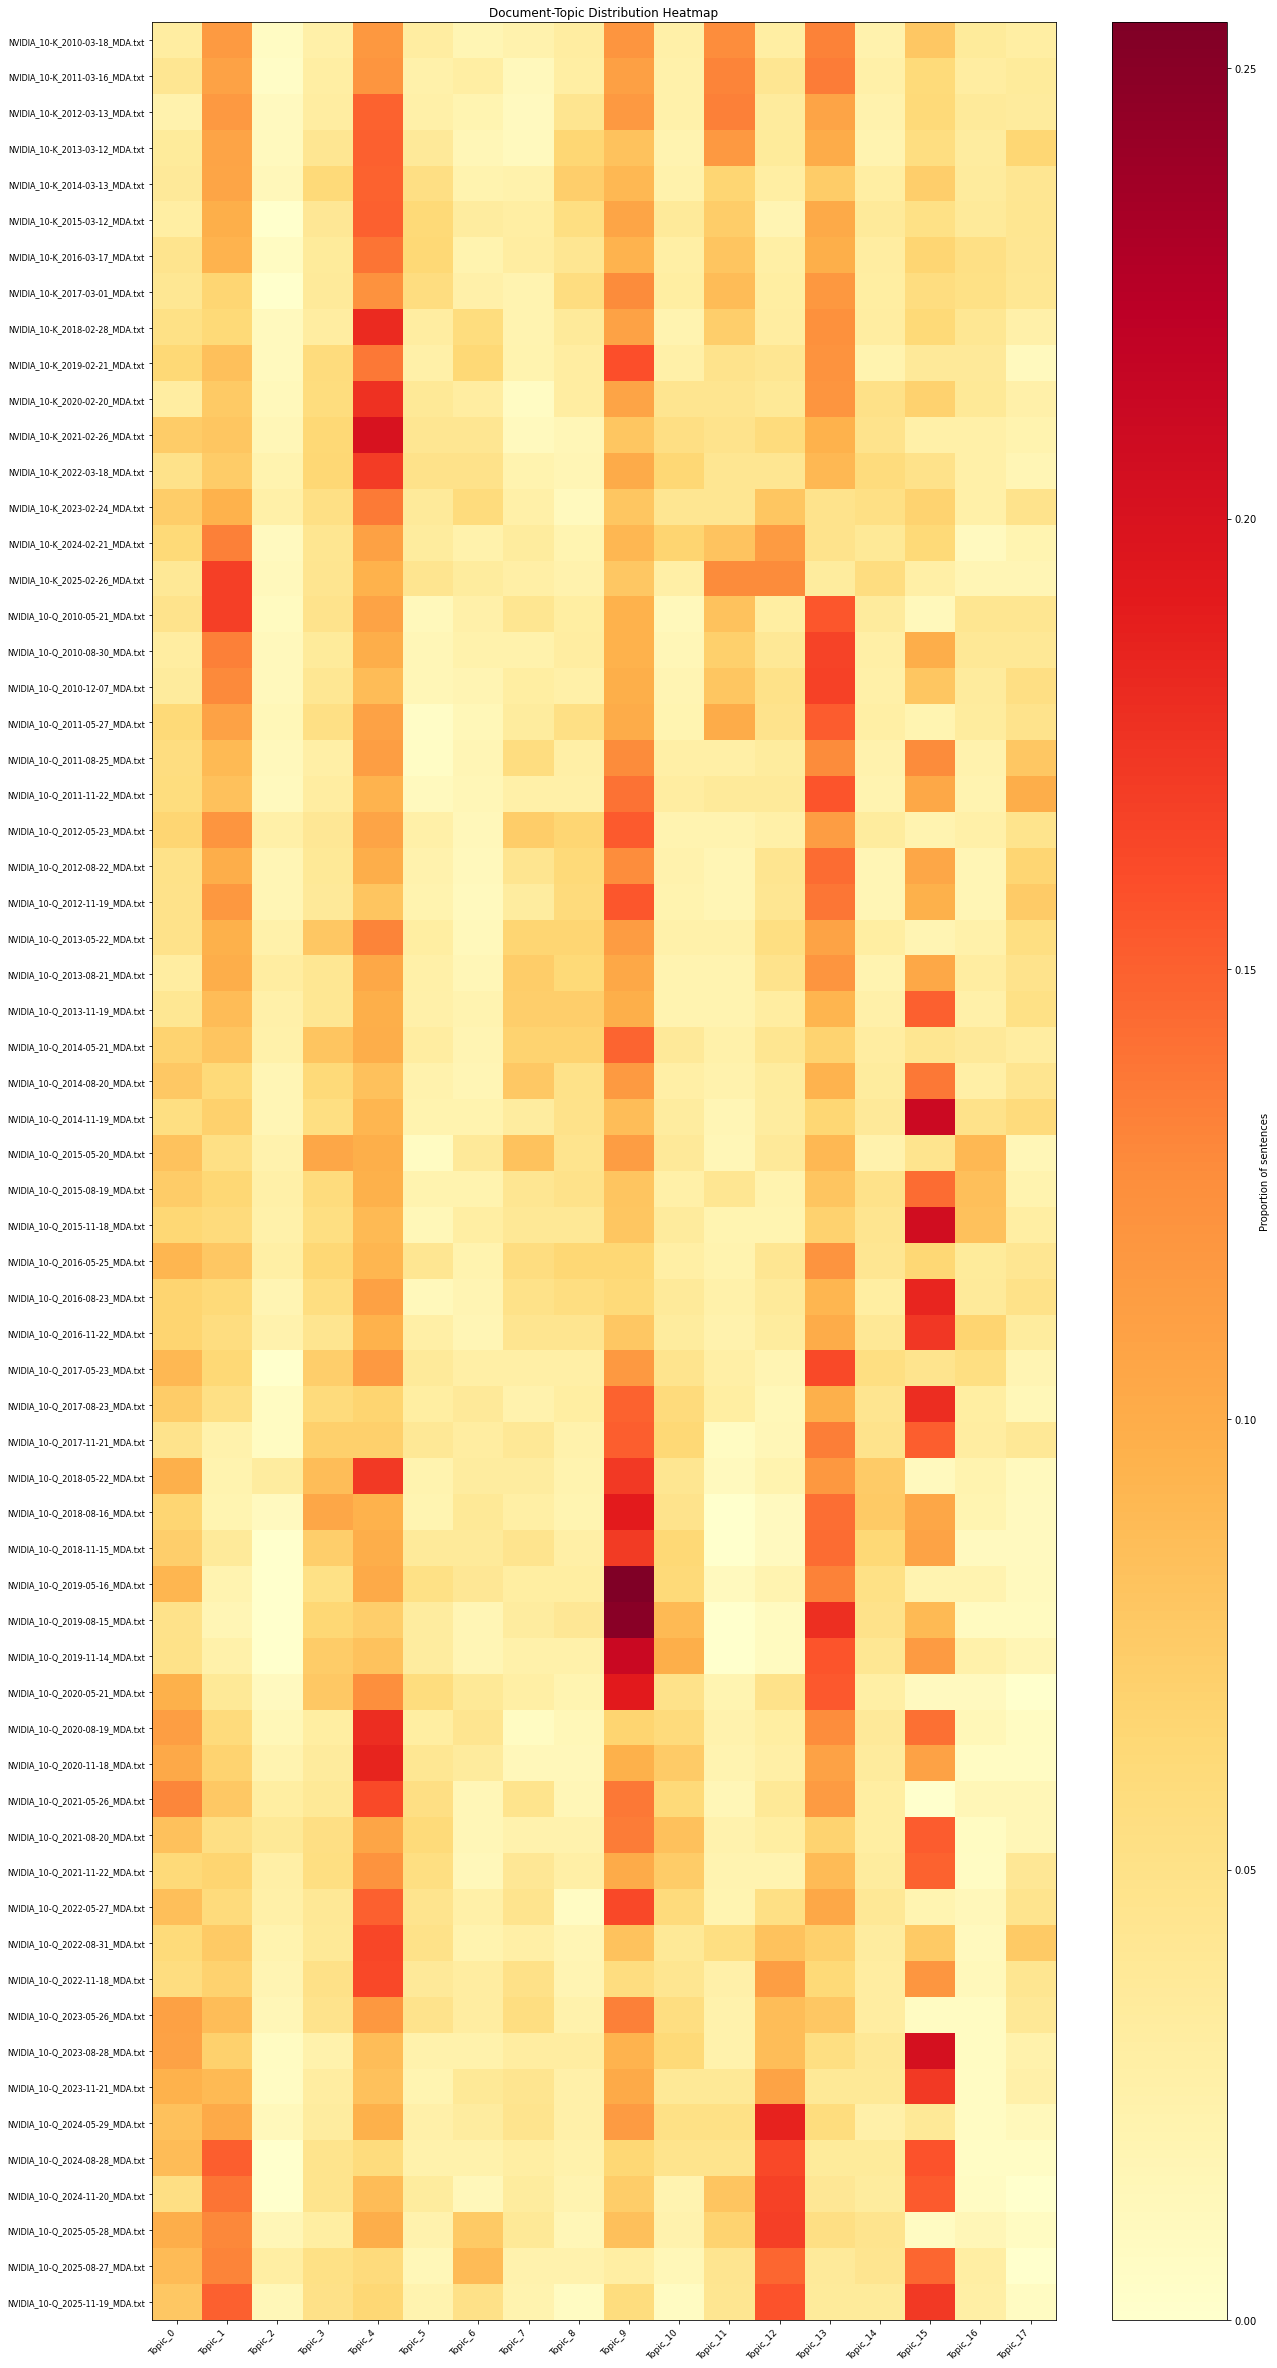

In [ ]:
# Heatmap
fig, ax = plt.subplots(figsize=(max(8, best_n), max(4, len(doc_topic_dist_pct) * 0.5 + 1)))
im = ax.imshow(doc_topic_dist_pct.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(doc_topic_dist_pct.columns)))
ax.set_xticklabels(doc_topic_dist_pct.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(doc_topic_dist_pct.index)))
ax.set_yticklabels(doc_topic_dist_pct.index, fontsize=8)

plt.colorbar(im, ax=ax, label='Proportion of sentences')
ax.set_title('Document-Topic Distribution Heatmap', fontsize=12)
plt.tight_layout()
plt.savefig('doc_topic_heatmap.png', dpi=150)
plt.show()